# Curve Curation Walkthrough: Hail x Solar

This is the **start-here notebook** for understanding how the `hail_solar` curve is curated.

The companion runtime notebook, `01_runtime_curve_walkthrough.ipynb`, starts from the finished JSON artifact and asks: **how do I evaluate this curve?**

This notebook starts one step earlier and asks: **how did we decide what this curve should be?**

It walks through the curation chain:

```text
scope and grain
  -> evidence inventory
  -> source interpretation
  -> anchor selection
  -> curve-form choice
  -> parameter fitting
  -> selector variants
  -> conditioner adjustments
  -> exposure/value logic
  -> capability and open seams
```

The formal source of truth is still the cell package under `docs/`. This notebook is the teaching and QA companion.


## What This Notebook Should Make Clear

By the end, you should be able to explain:

1. Why the curve is at **failure-unit grain**, not whole-asset grain.
2. Why the x-axis is MESH-equivalent hail diameter in mm.
3. How public evidence becomes interpreted anchors.
4. How the logistic parameters `D50` and `k` are fitted.
5. Why module archetype is a **selector**.
6. Why stow is a **conditioner** and why its numeric adjustment is labeled a placeholder.
7. Why exposure/value fractions are not curve-shape changes.
8. What evidence exists, what is assumed, and what would upgrade the curve.


In [1]:
from pathlib import Path
import json
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

pd.set_option("display.max_colwidth", 140)
pd.set_option("display.width", 180)

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "AGENTS.md").exists() and (candidate / "docs/damage_curves").exists():
            return candidate
    raise RuntimeError("Could not find damage_modeling repo root.")


REPO_ROOT = find_repo_root(Path.cwd())
CELL_DIR = REPO_ROOT / "docs/damage_curves/damage_curve_implementation/DAMAGE_CURVE_LIBRARY_V2_5_IMPLEMENTATION_HARDENED_DELIVERABLE/01_cells/hail_solar/current"
GLOBAL_METHOD_DIR = REPO_ROOT / "docs/damage_curves/damage_curve_implementation/DAMAGE_CURVE_LIBRARY_V2_5_IMPLEMENTATION_HARDENED_DELIVERABLE/00_global_method"
ARTIFACT_PATH = CELL_DIR / "hail_solar__model_v1_0__docs_r5__curve_artifact.json"
DOSSIER_PATH = CELL_DIR / "hail_solar_curve_derivation_dossier_v1_3.md"
OUTPUT_DIR = REPO_ROOT / "notebooks/hail/solar/outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

with ARTIFACT_PATH.open("r", encoding="utf-8") as f:
    artifact = json.load(f)

assert artifact["canonical_runtime_artifact"] is True

print(f"repo root : {REPO_ROOT}")
print(f"artifact  : {ARTIFACT_PATH.relative_to(REPO_ROOT)}")
print(f"dossier   : {DOSSIER_PATH.relative_to(REPO_ROOT)}")
print(f"outputs   : {OUTPUT_DIR.relative_to(REPO_ROOT)}")


repo root : /Users/divy/code/work/infrasure_git_codes/damage_modeling
artifact  : docs/damage_curves/damage_curve_implementation/DAMAGE_CURVE_LIBRARY_V2_5_IMPLEMENTATION_HARDENED_DELIVERABLE/01_cells/hail_solar/current/hail_solar__model_v1_0__docs_r5__curve_artifact.json
dossier   : docs/damage_curves/damage_curve_implementation/DAMAGE_CURVE_LIBRARY_V2_5_IMPLEMENTATION_HARDENED_DELIVERABLE/01_cells/hail_solar/current/hail_solar_curve_derivation_dossier_v1_3.md
outputs   : notebooks/hail/solar/outputs


## 1. The Global Curation Standard

The library standard says a derivation dossier must be a proof trail, not just a pretty curve. The required trail is:

```text
source evidence
   -> source interpretation
   -> anchor selection
   -> curve-form decision
   -> parameter fitting
   -> selector variants
   -> conditioner transformations
   -> exposure/value scaling rules
   -> assumptions and open seams
```

This notebook follows that order for one concrete cell.


,step,stage,question,hail_solar_example
0,1,Source evidence,What do public/lab/standard sources actually say?,PVEL/Kiwa hail stress results; IEC baseline; NOAA/MESH axis context
1,2,Source interpretation,What model fact can we extract without overclaiming?,"Glass breakage is treated as replacement DR proxy; IEC is near-zero anchor, not a full curve"
2,3,Anchor selection,Which points constrain the curve?,"Default: 25mm/1%, 50mm/39%; fragile: five public anchors; hardened: sparse two-anchor fit"
3,4,Curve-form decision,Which functional form is honest for sparse monotone evidence?,Bounded logistic
4,5,Parameter fitting,What math turns anchors into parameters?,Two-anchor logistic or logit-space least squares
5,6,Selectors,Which fixed asset attributes choose different curve families?,module_archetype -> fragile/default/hardened
6,7,Conditioners,Which event-time states shift/blend the selected curve?,stow_state -> D50 + 8mm and max_DR 0.90 blend; T4 placeholder
7,8,Exposure/value,How much value does the curve apply to after a hit?,array_exposure_fraction and f_hail_material_share
8,9,Capability/open seams,What can the artifact honestly support today?,Scalar DR yes; tail metrics withheld; claims/stow/exposure upgrades listed


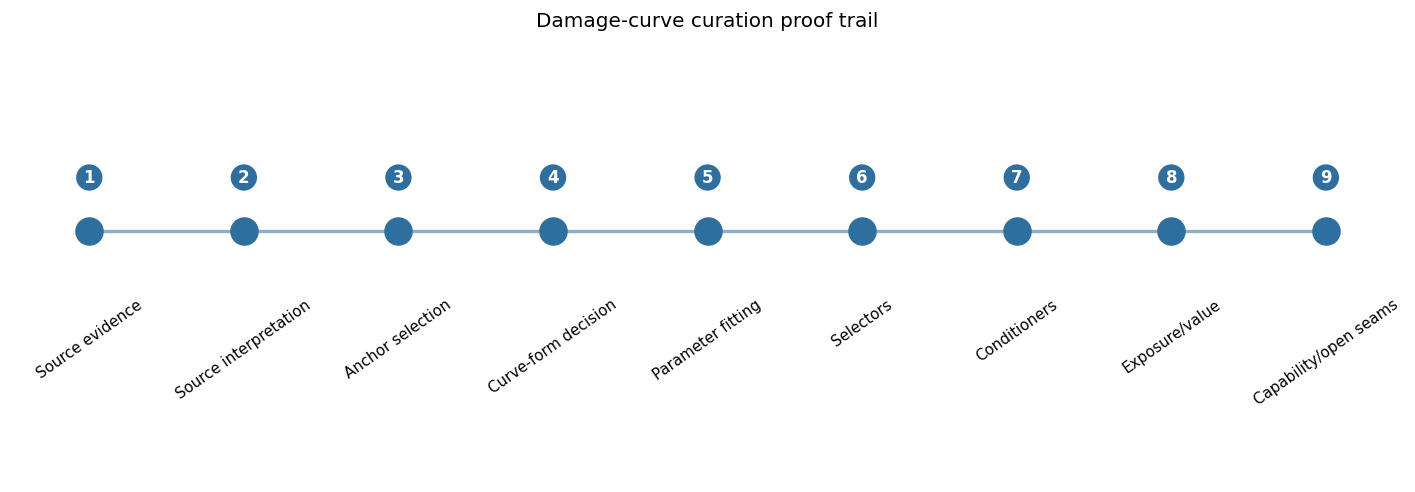

In [2]:
proof_trail = pd.DataFrame([
    {"step": 1, "stage": "Source evidence", "question": "What do public/lab/standard sources actually say?", "hail_solar_example": "PVEL/Kiwa hail stress results; IEC baseline; NOAA/MESH axis context"},
    {"step": 2, "stage": "Source interpretation", "question": "What model fact can we extract without overclaiming?", "hail_solar_example": "Glass breakage is treated as replacement DR proxy; IEC is near-zero anchor, not a full curve"},
    {"step": 3, "stage": "Anchor selection", "question": "Which points constrain the curve?", "hail_solar_example": "Default: 25mm/1%, 50mm/39%; fragile: five public anchors; hardened: sparse two-anchor fit"},
    {"step": 4, "stage": "Curve-form decision", "question": "Which functional form is honest for sparse monotone evidence?", "hail_solar_example": "Bounded logistic"},
    {"step": 5, "stage": "Parameter fitting", "question": "What math turns anchors into parameters?", "hail_solar_example": "Two-anchor logistic or logit-space least squares"},
    {"step": 6, "stage": "Selectors", "question": "Which fixed asset attributes choose different curve families?", "hail_solar_example": "module_archetype -> fragile/default/hardened"},
    {"step": 7, "stage": "Conditioners", "question": "Which event-time states shift/blend the selected curve?", "hail_solar_example": "stow_state -> D50 + 8mm and max_DR 0.90 blend; T4 placeholder"},
    {"step": 8, "stage": "Exposure/value", "question": "How much value does the curve apply to after a hit?", "hail_solar_example": "array_exposure_fraction and f_hail_material_share"},
    {"step": 9, "stage": "Capability/open seams", "question": "What can the artifact honestly support today?", "hail_solar_example": "Scalar DR yes; tail metrics withheld; claims/stow/exposure upgrades listed"},
])
display(proof_trail)

fig, ax = plt.subplots(figsize=(12, 4.2))
ax.scatter(proof_trail["step"], [1] * len(proof_trail), s=260, color="#2f6f9f", zorder=3)
ax.plot(proof_trail["step"], [1] * len(proof_trail), color="#2f6f9f", lw=2, alpha=0.55)
for _, row in proof_trail.iterrows():
    ax.text(row["step"], 1.08, str(row["step"]), ha="center", va="bottom", color="white", fontweight="bold",
            bbox=dict(boxstyle="circle,pad=0.25", facecolor="#2f6f9f", edgecolor="none"))
    ax.text(row["step"], 0.88, row["stage"], ha="center", va="top", rotation=35, fontsize=9)
ax.set_title("Damage-curve curation proof trail")
ax.set_xlim(0.5, 9.5)
ax.set_ylim(0.55, 1.35)
ax.axis("off")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "00_curation_proof_trail.png", dpi=180, bbox_inches="tight")
plt.show()


## 2. Scope First: Cell, Failure Unit, X-Axis, Y-Axis

Before fitting anything, the cell decides what the curve is allowed to mean.

For hail x solar v1:

```text
cell          = hail x solar
failure unit  = PV_MODULE_GLASS_CELL
x-axis        = MESH-equivalent hail diameter, mm
y-axis        = PV module glass/cell replacement damage ratio
```

This prevents the common mistake: applying a module breakage curve to the whole solar plant TIV.


In [3]:
identity = pd.DataFrame([
    {"item": "cell", "value": artifact["cell_id"]},
    {"item": "damage_code_id", "value": artifact["damage_code_id"]},
    {"item": "semantic_model_version", "value": artifact["semantic_damage_model_version"]},
    {"item": "documentation_revision", "value": artifact["documentation_revision"]},
    {"item": "canonical_runtime_artifact", "value": artifact["canonical_runtime_artifact"]},
])
display(identity)

display(Markdown("**Hazard axis**"))
display(pd.DataFrame([artifact["hazard_axis"]]))

display(Markdown("**Failure unit record**"))
display(pd.DataFrame(artifact["failure_units"]))


,item,value
0,cell,hail_solar
1,damage_code_id,HAIL_SOLAR_PV_MODULE_V1
2,semantic_model_version,model v1.0
3,documentation_revision,docs r5
4,canonical_runtime_artifact,True


**Hazard axis**

,id,input_field,unit,source_units_allowed,valid_range,extrapolation_policy
0,HAIL_DIAMETER_MESH_EQUIV,mesh_diameter_mm,mm,"[mm, in]","[0, 100]",clamp_or_warn


**Failure unit record**

,id,subsystem,component,treatment,y_axis,value_bucket,f_kind
0,PV_MODULE_GLASS_CELL,PV_ARRAY,PV_MODULE,primary_nonzero,module replacement damage ratio approximated by glass breakage probability,PV_ARRAY_MODULE_EXPOSED,material_share


## 3. Evidence Inventory: What Each Source Class Is Allowed To Do

A source can be strong for one purpose and weak for another. The curation discipline is to assign each source a role, then avoid using it beyond that role.

For example, IEC hail testing is useful as a near-zero boundary/standard anchor. It is not a full field-loss curve.


In [4]:
evidence_classes = pd.DataFrame([
    {
        "evidence_class": "Operational hazard data",
        "source_examples": "NOAA Storm Events; NOAA/NWS MESH",
        "role_in_curve": "Selects operational x-axis and units",
        "constraint_strength": "Strong for axis; not damage evidence",
    },
    {
        "evidence_class": "Standards / qualification",
        "source_examples": "IEC 61215 via DOE/FEMP",
        "role_in_curve": "Near-zero baseline; diameter-to-mass/velocity bridge",
        "constraint_strength": "Boundary/anchor, not full curve",
    },
    {
        "evidence_class": "Lab aggregate breakage data",
        "source_examples": "PVEL/Kiwa Hail Stress Sequence",
        "role_in_curve": "Main module archetype breakage anchors",
        "constraint_strength": "Strongest public parameter evidence",
    },
    {
        "evidence_class": "Field performance context",
        "source_examples": "NREL extreme weather PV performance; PVEL whitepaper",
        "role_in_curve": "Mechanism/caveat: latent cracking vs glass breakage",
        "constraint_strength": "Context, not direct replacement-cost curve",
    },
    {
        "evidence_class": "Operational mitigation guidance",
        "source_examples": "VDE hail stow; DOE/FEMP; FTC Solar stow announcement",
        "role_in_curve": "Supports direction of stow benefit",
        "constraint_strength": "Direction supported; generic numeric magnitude not calibrated",
    },
])
display(evidence_classes)

source_urls = pd.DataFrame([
    {"source_id": "NOAA_STORM_EVENTS", "what_it_supports": "hail-size reporting axis", "url": "https://www.ncei.noaa.gov/stormevents/faq.jsp"},
    {"source_id": "NOAA_MESH", "what_it_supports": "MESH maximum hail-size operational axis", "url": "https://vlab.noaa.gov/web/wdtd/-/maximum-estimated-size-of-hail-mes-2"},
    {"source_id": "DOE_FEMP_HAIL_GUIDANCE", "what_it_supports": "IEC hail test context; mitigation/stow direction", "url": "https://www.energy.gov/femp/hail-damage-mitigation-solar-photovoltaic-systems"},
    {"source_id": "PVEL_2023_HSS", "what_it_supports": "public module hail breakage anchors", "url": "https://2023modulescorecard.pvel.com/hail-stress-sequence/"},
    {"source_id": "KIWA_PVEL_HSS", "what_it_supports": "public module hail breakage anchors", "url": "https://scorecard.pvel.com/hail-stress-sequence/"},
    {"source_id": "PVEL_WHITEPAPER", "what_it_supports": "glass breakage vs latent performance context", "url": "https://www.pvel.com/wp-content/uploads/PVEL_White-Paper_Hail-Stress-Sequence-for-PV-Modules.pdf"},
    {"source_id": "NREL_EXTREME_WEATHER_PV", "what_it_supports": "field performance context", "url": "https://research-hub.nrel.gov/en/publications/extreme-weather-and-pv-performance-2"},
    {"source_id": "E_VDE_HAIL_STOW", "what_it_supports": "direction of stow benefit", "url": "https://www.vde.com/en/vde-americas/newsroom/hail-stow-tech-memo"},
    {"source_id": "FTC_SOLAR_STOW", "what_it_supports": "operational availability of high-angle hail stow", "url": "https://investor.ftcsolar.com/news-releases/news-release-details/ftc-solar-launches-automated-80deg-high-angle-stow-1p-pioneer/"},
])
display(source_urls)


,evidence_class,source_examples,role_in_curve,constraint_strength
0,Operational hazard data,NOAA Storm Events; NOAA/NWS MESH,Selects operational x-axis and units,Strong for axis; not damage evidence
1,Standards / qualification,IEC 61215 via DOE/FEMP,Near-zero baseline; diameter-to-mass/velocity bridge,"Boundary/anchor, not full curve"
2,Lab aggregate breakage data,PVEL/Kiwa Hail Stress Sequence,Main module archetype breakage anchors,Strongest public parameter evidence
3,Field performance context,NREL extreme weather PV performance; PVEL whitepaper,Mechanism/caveat: latent cracking vs glass breakage,"Context, not direct replacement-cost curve"
4,Operational mitigation guidance,VDE hail stow; DOE/FEMP; FTC Solar stow announcement,Supports direction of stow benefit,Direction supported; generic numeric magnitude not calibrated


,source_id,what_it_supports,url
0,NOAA_STORM_EVENTS,hail-size reporting axis,https://www.ncei.noaa.gov/stormevents/faq.jsp
1,NOAA_MESH,MESH maximum hail-size operational axis,https://vlab.noaa.gov/web/wdtd/-/maximum-estimated-size-of-hail-mes-2
2,DOE_FEMP_HAIL_GUIDANCE,IEC hail test context; mitigation/stow direction,https://www.energy.gov/femp/hail-damage-mitigation-solar-photovoltaic-systems
3,PVEL_2023_HSS,public module hail breakage anchors,https://2023modulescorecard.pvel.com/hail-stress-sequence/
4,KIWA_PVEL_HSS,public module hail breakage anchors,https://scorecard.pvel.com/hail-stress-sequence/
5,PVEL_WHITEPAPER,glass breakage vs latent performance context,https://www.pvel.com/wp-content/uploads/PVEL_White-Paper_Hail-Stress-Sequence-for-PV-Modules.pdf
6,NREL_EXTREME_WEATHER_PV,field performance context,https://research-hub.nrel.gov/en/publications/extreme-weather-and-pv-performance-2
7,E_VDE_HAIL_STOW,direction of stow benefit,https://www.vde.com/en/vde-americas/newsroom/hail-stow-tech-memo
8,FTC_SOLAR_STOW,operational availability of high-angle hail stow,https://investor.ftcsolar.com/news-releases/news-release-details/ftc-solar-launches-automated-80deg-high-angle-stow-1p-pioneer/


## 4. Source Interpretation: Raw Evidence Becomes Model Anchors

The curation step is not simply copying numbers. We decide what each source statement means for this model.

Examples:

- `25 mm -> 1%` for the default curve is an interpreted near-zero certification anchor, not a measured field-loss point.
- `50 mm -> 39%` is a public aggregate breakage anchor, not a guarantee for a specific module BOM.
- Hardened anchors are sparse, so the hardened curve is explicitly lower-confidence / extrapolated.


In [5]:
anchors = pd.DataFrame([
    # Default curve: two-anchor fit.
    {"curve_id": "HAIL_SOLAR_DEFAULT_3P2_GBS", "archetype": "default 3.2mm glass/backsheet", "D_mm": 25.0, "p_break": 0.010, "source_role": "IEC baseline near-zero interpreted anchor", "tier": "T2", "fit_method": "two_anchor"},
    {"curve_id": "HAIL_SOLAR_DEFAULT_3P2_GBS", "archetype": "default 3.2mm glass/backsheet", "D_mm": 50.0, "p_break": 0.390, "source_role": "PVEL 2023 public aggregate breakage anchor", "tier": "T2", "fit_method": "two_anchor"},

    # Fragile curve: logit-space least-squares fit.
    {"curve_id": "HAIL_SOLAR_FRAGILE_THIN_GG", "archetype": "fragile thin glass/glass", "D_mm": 35.0, "p_break": 0.180, "source_role": "PVEL 2023 public aggregate anchor", "tier": "T2", "fit_method": "logit_lstsq"},
    {"curve_id": "HAIL_SOLAR_FRAGILE_THIN_GG", "archetype": "fragile thin glass/glass", "D_mm": 40.0, "p_break": 0.570, "source_role": "PVEL 2023 public aggregate anchor", "tier": "T2", "fit_method": "logit_lstsq"},
    {"curve_id": "HAIL_SOLAR_FRAGILE_THIN_GG", "archetype": "fragile thin glass/glass", "D_mm": 40.0, "p_break": 0.430, "source_role": "Kiwa/PVEL public aggregate anchor", "tier": "T2", "fit_method": "logit_lstsq"},
    {"curve_id": "HAIL_SOLAR_FRAGILE_THIN_GG", "archetype": "fragile thin glass/glass", "D_mm": 45.0, "p_break": 0.610, "source_role": "Kiwa/PVEL public aggregate anchor", "tier": "T2", "fit_method": "logit_lstsq"},
    {"curve_id": "HAIL_SOLAR_FRAGILE_THIN_GG", "archetype": "fragile thin glass/glass", "D_mm": 50.0, "p_break": 0.890, "source_role": "PVEL 2023 public aggregate anchor", "tier": "T2", "fit_method": "logit_lstsq"},

    # Hardened curve: sparse two-anchor fit.
    {"curve_id": "HAIL_SOLAR_HARDENED_THICKER", "archetype": "hardened / thicker glass", "D_mm": 25.0, "p_break": 0.005, "source_role": "IEC hardened near-zero interpreted anchor", "tier": "T3", "fit_method": "two_anchor"},
    {"curve_id": "HAIL_SOLAR_HARDENED_THICKER", "archetype": "hardened / thicker glass", "D_mm": 45.0, "p_break": 0.070, "source_role": "PVEL/Kiwa hardened public result", "tier": "T3", "fit_method": "two_anchor"},
])

display(anchors)


,curve_id,archetype,D_mm,p_break,source_role,tier,fit_method
0,HAIL_SOLAR_DEFAULT_3P2_GBS,default 3.2mm glass/backsheet,25.0,0.010,IEC baseline near-zero interpreted anchor,T2,two_anchor
1,HAIL_SOLAR_DEFAULT_3P2_GBS,default 3.2mm glass/backsheet,50.0,0.390,PVEL 2023 public aggregate breakage anchor,T2,two_anchor
2,HAIL_SOLAR_FRAGILE_THIN_GG,fragile thin glass/glass,35.0,0.180,PVEL 2023 public aggregate anchor,T2,logit_lstsq
3,HAIL_SOLAR_FRAGILE_THIN_GG,fragile thin glass/glass,40.0,0.570,PVEL 2023 public aggregate anchor,T2,logit_lstsq
4,HAIL_SOLAR_FRAGILE_THIN_GG,fragile thin glass/glass,40.0,0.430,Kiwa/PVEL public aggregate anchor,T2,logit_lstsq
5,HAIL_SOLAR_FRAGILE_THIN_GG,fragile thin glass/glass,45.0,0.610,Kiwa/PVEL public aggregate anchor,T2,logit_lstsq
6,HAIL_SOLAR_FRAGILE_THIN_GG,fragile thin glass/glass,50.0,0.890,PVEL 2023 public aggregate anchor,T2,logit_lstsq
7,HAIL_SOLAR_HARDENED_THICKER,hardened / thicker glass,25.0,0.005,IEC hardened near-zero interpreted anchor,T3,two_anchor
8,HAIL_SOLAR_HARDENED_THICKER,hardened / thicker glass,45.0,0.070,PVEL/Kiwa hardened public result,T3,two_anchor


## 5. Curve-Form Choice: Why Logistic?

The chosen base form is:

```text
P_break(D) = max_DR / (1 + exp(-k * (D - D50)))
```

Why this form is reasonable for v1:

- bounded between 0 and 1;
- monotone with hail size;
- threshold-like without a hard step;
- parameter meanings are explainable (`D50`, `k`);
- works with sparse anchor evidence without pretending we have a dense claims curve.

This does **not** claim nature is exactly logistic. It is a controlled v1 approximation.


In [6]:
curve_form_alternatives = pd.DataFrame([
    {"form": "Step threshold", "why_considered": "Certification pass/fail logic", "decision": "Not selected", "reason": "Too discontinuous for expected replacement DR"},
    {"form": "Piecewise linear", "why_considered": "Transparent sparse anchors", "decision": "Not selected for runtime", "reason": "Creates artificial kinks and unstable extrapolation"},
    {"form": "Bounded logistic", "why_considered": "Monotone bounded transition", "decision": "Selected", "reason": "Interpretable D50/k; good v1 fit to sparse breakage anchors"},
    {"form": "Damage-state probabilities", "why_considered": "Would represent multiple severity states", "decision": "Future", "reason": "Public evidence does not yet support a state table for this cell"},
    {"form": "Claims empirical curve", "why_considered": "Would be ideal for insured replacement losses", "decision": "Future", "reason": "No private claims calibration in current package"},
])
display(curve_form_alternatives)


,form,why_considered,decision,reason
0,Step threshold,Certification pass/fail logic,Not selected,Too discontinuous for expected replacement DR
1,Piecewise linear,Transparent sparse anchors,Not selected for runtime,Creates artificial kinks and unstable extrapolation
2,Bounded logistic,Monotone bounded transition,Selected,Interpretable D50/k; good v1 fit to sparse breakage anchors
3,Damage-state probabilities,Would represent multiple severity states,Future,Public evidence does not yet support a state table for this cell
4,Claims empirical curve,Would be ideal for insured replacement losses,Future,No private claims calibration in current package


## 6. Fitting Math: Anchors To `D50` And `k`

For `max_DR = 1`, the logistic is:

```text
p = 1 / (1 + exp(-k * (D - D50)))
```

Taking logit:

```text
logit(p) = ln(p / (1 - p)) = k * D - k * D50
```

For two anchors:

```text
k = [logit(p2) - logit(p1)] / (D2 - D1)
D50 = D1 - logit(p1) / k
```

For more than two anchors, fit a line in logit-space:

```text
logit(p_i) = k * D_i - k * D50
```


In [7]:
def logit(p):
    p = np.asarray(p, dtype=float)
    return np.log(p / (1.0 - p))


def logistic(D, D50_mm, k_per_mm, max_DR=1.0):
    D = np.asarray(D, dtype=float)
    return max_DR / (1.0 + np.exp(-k_per_mm * (D - D50_mm)))


def two_anchor_fit(df):
    df = df.sort_values("D_mm")
    D1, p1 = df.iloc[0][["D_mm", "p_break"]]
    D2, p2 = df.iloc[1][["D_mm", "p_break"]]
    k = (logit(p2) - logit(p1)) / (D2 - D1)
    D50 = D1 - logit(p1) / k
    return {"D50_mm_fit": float(D50), "k_per_mm_fit": float(k)}


def logit_lstsq_fit(df):
    x = df["D_mm"].to_numpy(dtype=float)
    y = logit(df["p_break"].to_numpy(dtype=float))
    slope, intercept = np.polyfit(x, y, deg=1)
    k = slope
    D50 = -intercept / slope
    return {"D50_mm_fit": float(D50), "k_per_mm_fit": float(k)}

fit_rows = []
for curve_id, group in anchors.groupby("curve_id"):
    method = group["fit_method"].iloc[0]
    fit = two_anchor_fit(group) if method == "two_anchor" else logit_lstsq_fit(group)
    artifact_rec = next(rec for rec in artifact["curve_records"] if rec["curve_id"] == curve_id)
    params = artifact_rec["parameters"]
    fit_rows.append({
        "curve_id": curve_id,
        "fit_method": method,
        "D50_mm_fit": fit["D50_mm_fit"],
        "D50_mm_artifact": params["D50_mm"],
        "D50_delta_mm": fit["D50_mm_fit"] - params["D50_mm"],
        "k_fit": fit["k_per_mm_fit"],
        "k_artifact": params["k_per_mm"],
        "k_delta": fit["k_per_mm_fit"] - params["k_per_mm"],
    })
fits = pd.DataFrame(fit_rows)
display(fits.style.format({
    "D50_mm_fit": "{:.6f}", "D50_mm_artifact": "{:.6f}", "D50_delta_mm": "{:.6e}",
    "k_fit": "{:.6f}", "k_artifact": "{:.6f}", "k_delta": "{:.6e}",
}))


,curve_id,fit_method,D50_mm_fit,D50_mm_artifact,D50_delta_mm,k_fit,k_artifact,k_delta
0,HAIL_SOLAR_DEFAULT_3P2_GBS,two_anchor,52.696076,52.696000,7.620290e-05,0.165912,0.165912,3.052836e-07
1,HAIL_SOLAR_FRAGILE_THIN_GG,logit_lstsq,41.073842,41.074000,-1.584131e-04,0.220633,0.220633,6.042444e-08
2,HAIL_SOLAR_HARDENED_THICKER,two_anchor,64.113830,64.114000,-1.704766e-04,0.135331,0.135331,-2.259687e-07


## 7. Visual QA: Do The Fitted Curves Match The Anchors?

This plot is one of the simplest and most useful review views. It shows whether the shipped curves are actually consistent with the interpreted anchors.

Remember: the points are not all equal quality. The hardened curve is intentionally weaker because it is fit from sparse public evidence.


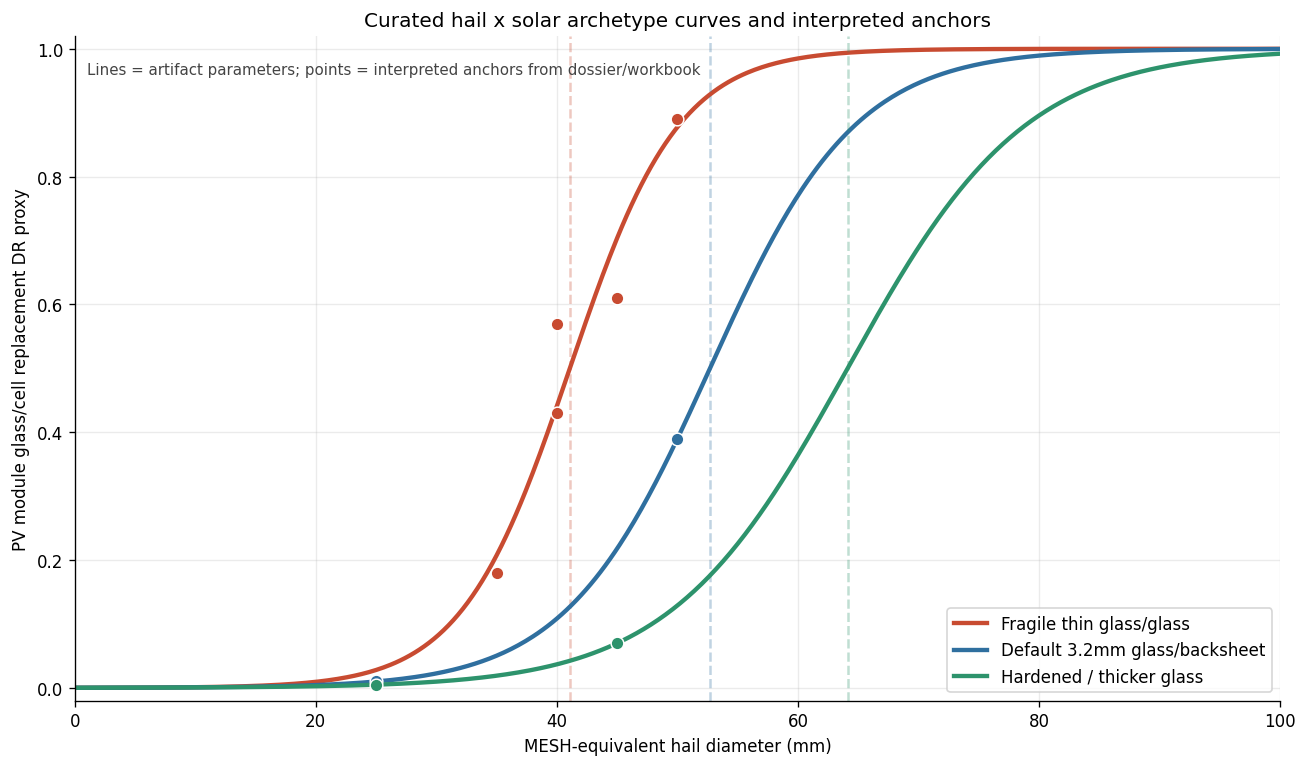

In [8]:
curve_labels = {
    "HAIL_SOLAR_FRAGILE_THIN_GG": "Fragile thin glass/glass",
    "HAIL_SOLAR_DEFAULT_3P2_GBS": "Default 3.2mm glass/backsheet",
    "HAIL_SOLAR_HARDENED_THICKER": "Hardened / thicker glass",
}
curve_colors = {
    "HAIL_SOLAR_FRAGILE_THIN_GG": "#c84b31",
    "HAIL_SOLAR_DEFAULT_3P2_GBS": "#2f6f9f",
    "HAIL_SOLAR_HARDENED_THICKER": "#2d936c",
}
D_grid = np.linspace(0, 100, 501)

fig, ax = plt.subplots(figsize=(11, 6.5))
for rec in artifact["curve_records"]:
    curve_id = rec["curve_id"]
    params = rec["parameters"]
    y = logistic(D_grid, params["D50_mm"], params["k_per_mm"], params.get("max_DR", 1.0))
    ax.plot(D_grid, y, lw=2.6, color=curve_colors[curve_id], label=curve_labels[curve_id])
    points = anchors[anchors["curve_id"] == curve_id]
    ax.scatter(points["D_mm"], points["p_break"], s=58, color=curve_colors[curve_id], edgecolor="white", linewidth=0.9, zorder=5)
    ax.axvline(params["D50_mm"], color=curve_colors[curve_id], linestyle="--", alpha=0.3)

ax.set_title("Curated hail x solar archetype curves and interpreted anchors")
ax.set_xlabel("MESH-equivalent hail diameter (mm)")
ax.set_ylabel("PV module glass/cell replacement DR proxy")
ax.set_xlim(0, 100)
ax.set_ylim(-0.02, 1.02)
ax.legend(loc="lower right")
ax.text(1, 0.96, "Lines = artifact parameters; points = interpreted anchors from dossier/workbook", fontsize=9, color="#444")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "00_curated_curves_with_anchors.png", dpi=180, bbox_inches="tight")
plt.show()


## 8. Logit-Space Fit View

The fragile curve uses multiple public aggregate anchors, so the fit is a line in logit space.

This is often easier to audit than the S-curve itself because the logistic becomes linear after the logit transform.


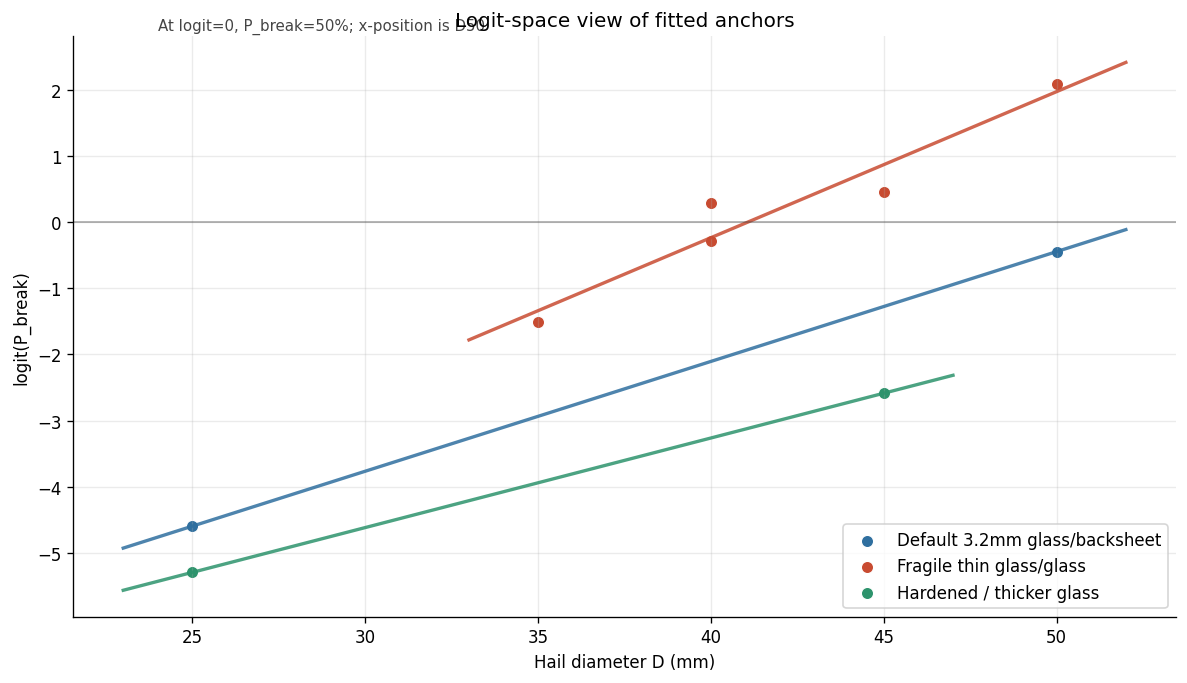

In [9]:
fig, ax = plt.subplots(figsize=(10, 5.8))
for curve_id, group in anchors.groupby("curve_id"):
    fit = fits[fits["curve_id"] == curve_id].iloc[0]
    x = group["D_mm"].to_numpy(dtype=float)
    y = logit(group["p_break"].to_numpy(dtype=float))
    color = curve_colors[curve_id]
    ax.scatter(x, y, s=55, color=color, edgecolor="white", linewidth=0.8, label=curve_labels[curve_id])
    xline = np.linspace(x.min() - 2, x.max() + 2, 50)
    yline = fit["k_fit"] * (xline - fit["D50_mm_fit"])
    ax.plot(xline, yline, color=color, lw=2, alpha=0.85)

ax.axhline(0, color="#444", lw=1, alpha=0.45)
ax.set_title("Logit-space view of fitted anchors")
ax.set_xlabel("Hail diameter D (mm)")
ax.set_ylabel("logit(P_break)")
ax.legend(loc="lower right")
ax.text(24, 2.9, "At logit=0, P_break=50%; x-position is D50", fontsize=9, color="#444")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "00_logit_fit_view.png", dpi=180, bbox_inches="tight")
plt.show()


## 9. Parameter Tiers: Evidence-Backed vs Placeholder

The fitted base curves are mostly T2/T3. The stow numeric adjustment is T4.

This is not just bookkeeping. It tells a reviewer which parts of the model can support confident use and which parts should be treated as upgrade targets.


,parameter,curve_id,value,param_role,tier,source_ids,reasoning,update_trigger
0,D50_mm,HAIL_SOLAR_FRAGILE_THIN_GG,41.074000,curve_fit_shape,T2_public_lab_standard_or_physics,"PVEL_2023_HSS, KIWA_PVEL_HSS",Fit from public aggregate lab breakage anchors for thin glass/glass modules.,module-specific BOM or larger public lab dataset
1,k_per_mm,HAIL_SOLAR_FRAGILE_THIN_GG,0.220633,curve_fit_shape,T2_public_lab_standard_or_physics,"PVEL_2023_HSS, KIWA_PVEL_HSS",Logit-space fit to public lab anchors.,module-specific BOM or larger public lab dataset
2,D50_mm,HAIL_SOLAR_DEFAULT_3P2_GBS,52.696000,curve_fit_shape,T2_public_lab_standard_or_physics,"IEC_61215_BASELINE, PVEL_2023_HSS",Two-anchor fit using IEC near-zero baseline and public PVEL 50mm glass/backsheet aggregate.,claims/OEM/BOM-specific calibration
3,k_per_mm,HAIL_SOLAR_DEFAULT_3P2_GBS,0.165912,curve_fit_shape,T2_public_lab_standard_or_physics,"IEC_61215_BASELINE, PVEL_2023_HSS",Two-anchor logistic slope.,claims/OEM/BOM-specific calibration
4,D50_mm,HAIL_SOLAR_HARDENED_THICKER,64.114000,curve_fit_shape,T3_engineering_proxy_or_adjacent_empirical,"IEC_61215_BASELINE, PVEL_KIWA_HARDENED_PUBLIC_RESULT",Sparse-anchor hardened extrapolation; requires evidence of hardened module design.,hardened module-specific lab/claims data
5,k_per_mm,HAIL_SOLAR_HARDENED_THICKER,0.135331,curve_fit_shape,T3_engineering_proxy_or_adjacent_empirical,"IEC_61215_BASELINE, PVEL_KIWA_HARDENED_PUBLIC_RESULT",Sparse two-anchor logistic slope; tail is extrapolated.,hardened module-specific lab/claims data
6,stowed_D50_shift_mm,all_hail_archetypes,8.000000,conditioner_adjustment,T4_placeholder_or_expert_judgment,"E_VDE_HAIL_STOW, DOE_FEMP_HAIL_GUIDANCE",Directional support for high-tilt mitigation; magnitude not publicly calibrated.,tracker-specific stow-angle impact testing
7,stowed_max_DR,all_hail_archetypes,0.900000,boundary_or_cap,T4_placeholder_or_expert_judgment,E_VDE_HAIL_STOW,Cap acknowledges residual high-severity breakage under extreme hail; not claims calibrated.,claims/lab stow performance data


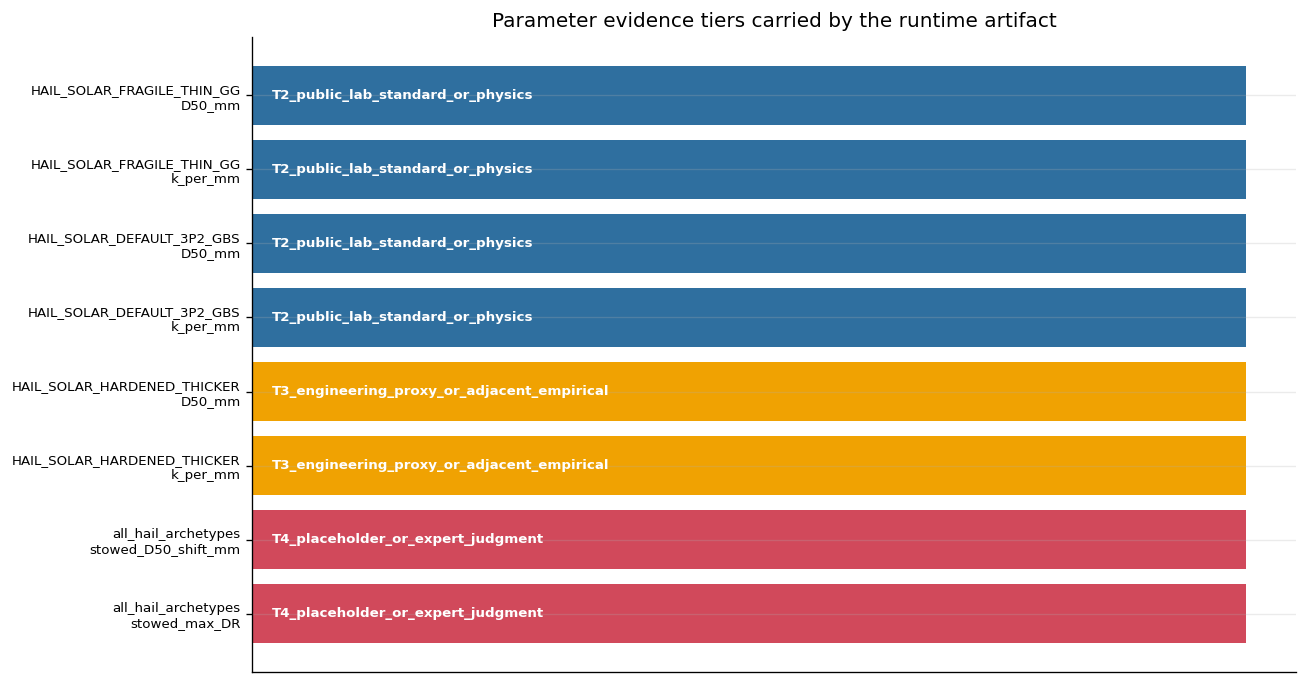

In [10]:
param_tiers = pd.DataFrame(artifact["parameter_tier_table"])
param_tiers["source_ids"] = param_tiers["source_ids"].apply(lambda xs: ", ".join(xs))
display(param_tiers)

# Compact visual: parameters by curve / tier.
tier_order = ["T1_private_claims_or_direct_empirical", "T2_public_lab_standard_or_physics", "T3_engineering_proxy_or_adjacent_empirical", "T4_placeholder_or_expert_judgment"]
tier_color = {
    "T1_private_claims_or_direct_empirical": "#1b9e77",
    "T2_public_lab_standard_or_physics": "#2f6f9f",
    "T3_engineering_proxy_or_adjacent_empirical": "#f0a202",
    "T4_placeholder_or_expert_judgment": "#d1495b",
}
plot_df = param_tiers.copy()
plot_df["row_label"] = plot_df["curve_id"] + "\n" + plot_df["parameter"]
fig, ax = plt.subplots(figsize=(11, 5.8))
ypos = np.arange(len(plot_df))
ax.barh(ypos, [1] * len(plot_df), color=[tier_color[t] for t in plot_df["tier"]])
ax.set_yticks(ypos)
ax.set_yticklabels(plot_df["row_label"], fontsize=8)
ax.set_xticks([])
ax.set_title("Parameter evidence tiers carried by the runtime artifact")
for y, (_, row) in zip(ypos, plot_df.iterrows()):
    ax.text(0.02, y, row["tier"], va="center", ha="left", color="white", fontsize=8, fontweight="bold")
ax.invert_yaxis()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "00_parameter_tier_view.png", dpi=180, bbox_inches="tight")
plt.show()


## 10. Selector Logic: Why Module Archetype Creates Curve Families

A selector is a fixed asset attribute that chooses a curve family.

For hail x solar, module construction can materially change breakage behavior. Because the evidence supports distinct archetype behavior, v1 ships three archetype curves rather than one curve with an unlabeled fudge factor.


In [11]:
selector_table = pd.DataFrame([
    {"field": "module_archetype", "role": "selector", "choice": "fragile_thin_glass_glass", "curve_id": "HAIL_SOLAR_FRAGILE_THIN_GG", "why": "thin glass/glass public anchors show earlier breakage transition"},
    {"field": "module_archetype", "role": "selector", "choice": "default_3_2mm_glass_backsheet", "curve_id": "HAIL_SOLAR_DEFAULT_3P2_GBS", "why": "modern baseline/default module archetype"},
    {"field": "module_archetype", "role": "selector", "choice": "hail_hardened_thicker_glass", "curve_id": "HAIL_SOLAR_HARDENED_THICKER", "why": "use only when module specs/test evidence support hardened classification"},
])
display(selector_table)

display(pd.DataFrame(artifact["selector_logic"]))


,field,role,choice,curve_id,why
0,module_archetype,selector,fragile_thin_glass_glass,HAIL_SOLAR_FRAGILE_THIN_GG,thin glass/glass public anchors show earlier breakage transition
1,module_archetype,selector,default_3_2mm_glass_backsheet,HAIL_SOLAR_DEFAULT_3P2_GBS,modern baseline/default module archetype
2,module_archetype,selector,hail_hardened_thicker_glass,HAIL_SOLAR_HARDENED_THICKER,use only when module specs/test evidence support hardened classification


,field,required,default,effect,missing_data_flag
0,module_archetype,True,default_3_2mm_glass_backsheet,chooses_curve_family,DEFAULT_SELECTOR_USED
1,front_glass_thickness_mm,False,NaN,maps_to_module_archetype,NaN
2,glass_glass_vs_backsheet,False,NaN,maps_to_module_archetype,NaN
3,hail_test_rating,False,NaN,can_create_exact_override,NaN


## 11. Conditioner Logic: Why Stow Is An Adjustment, Not A New Asset Curve

A conditioner is an event-time state. It changes the selected curve for that event, but it does not redefine the installed module archetype.

For stow:

```text
DR_conditioned(D)
  = P(stowed) * DR_stowed(D)
  + (1 - P(stowed)) * DR_unstowed(D)
```

Current v1 placeholder:

```text
DR_stowed(D) = 0.90 * logistic(D; D50 + 8mm, k)
```

The direction is evidence-supported. The exact `+8mm` and `0.90` are not tracker/BOM calibrated, so they are explicitly T4.


,adjustment_id,field,adjustment_type,form,source_ids,tier,reasoning,open_seam
0,HAIL_STOW_HORIZONTAL_SHIFT_V1,stow_state,probability_blend_of_unstowed_and_stowed_curves,"DR = P_stowed * [0.90 * logistic(D; D50+8mm, k)] + (1-P_stowed) * logistic(D; D50, k)","[E_VDE_HAIL_STOW, DOE_FEMP_HAIL_GUIDANCE]",T4_placeholder_or_expert_judgment,"Public sources support high-tilt/stow reducing normal impact severity, but do not provide a universal numeric shift. Horizontal shift pr...",replace with tracker/BOM-specific hail-stow test data


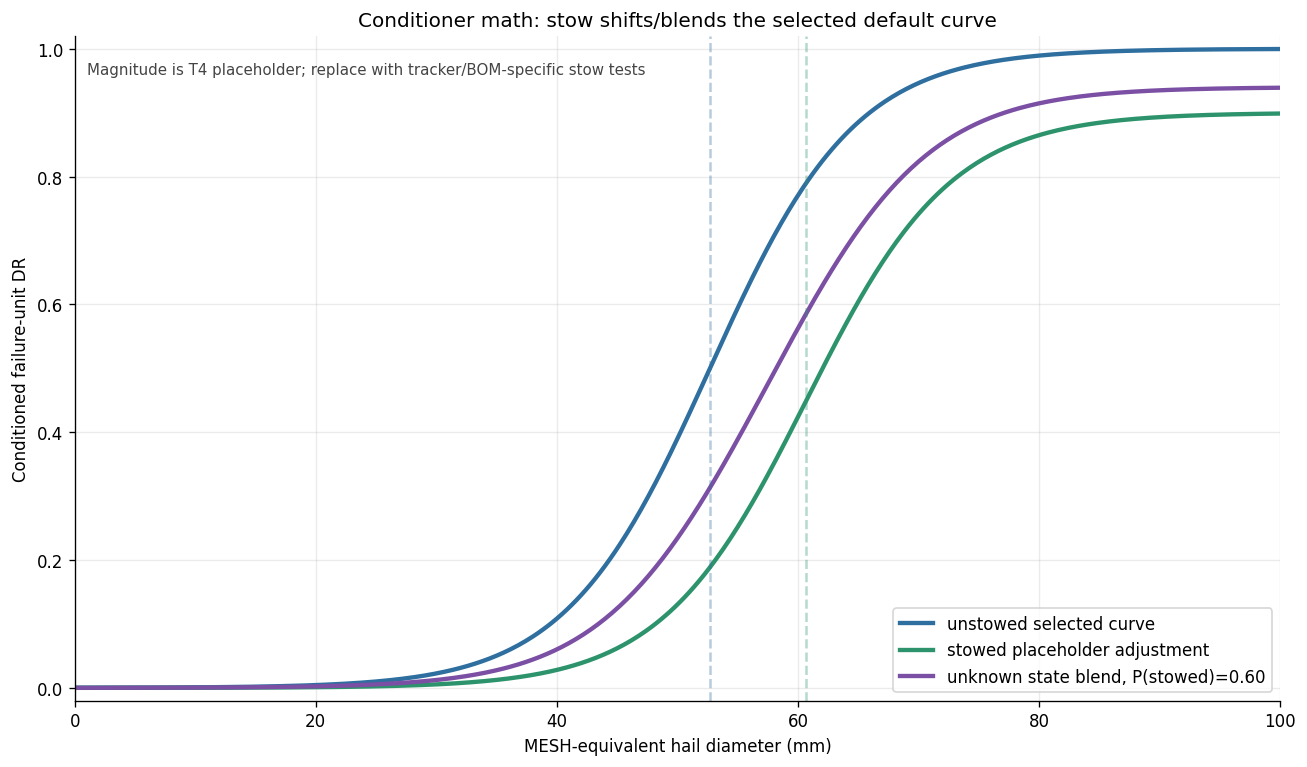

In [12]:
conditioner = artifact["conditioner_logic"][0]
display(pd.DataFrame([conditioner]))

base = next(rec for rec in artifact["curve_records"] if rec["curve_id"] == "HAIL_SOLAR_DEFAULT_3P2_GBS")
p = base["parameters"]
base_y = logistic(D_grid, p["D50_mm"], p["k_per_mm"], p.get("max_DR", 1.0))
stowed_y = logistic(D_grid, p["D50_mm"] + 8.0, p["k_per_mm"], 0.90 * p.get("max_DR", 1.0))
blend_y = 0.60 * stowed_y + 0.40 * base_y

fig, ax = plt.subplots(figsize=(11, 6.5))
ax.plot(D_grid, base_y, color="#2f6f9f", lw=2.6, label="unstowed selected curve")
ax.plot(D_grid, stowed_y, color="#2d936c", lw=2.6, label="stowed placeholder adjustment")
ax.plot(D_grid, blend_y, color="#7b4fa3", lw=2.6, label="unknown state blend, P(stowed)=0.60")
ax.axvline(p["D50_mm"], color="#2f6f9f", linestyle="--", alpha=0.35)
ax.axvline(p["D50_mm"] + 8.0, color="#2d936c", linestyle="--", alpha=0.35)
ax.set_title("Conditioner math: stow shifts/blends the selected default curve")
ax.set_xlabel("MESH-equivalent hail diameter (mm)")
ax.set_ylabel("Conditioned failure-unit DR")
ax.set_xlim(0, 100)
ax.set_ylim(-0.02, 1.02)
ax.legend(loc="lower right")
ax.text(1, 0.96, "Magnitude is T4 placeholder; replace with tracker/BOM-specific stow tests", fontsize=9, color="#444")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "00_stow_conditioner_curation.png", dpi=180, bbox_inches="tight")
plt.show()


## 12. Exposure And Value Logic: Do Not Change The Curve For A Value Problem

Exposure and value modifiers answer a different question from fragility.

```text
failure-unit DR = how damaged is the PV module glass/cell failure unit at this hail size?
array_exposure_fraction = how much of the array value is touched after a hit?
f_hail_material_share = what share of PV_ARRAY value is actually the module/glass-cell value bucket?
```

Therefore:

```text
loss_if_hit = DR(D) * array_exposure_fraction * PV_ARRAY_value * f_hail_material_share
```

or, if the valuation ledger already has the direct bucket:

```text
loss_if_hit = DR(D) * array_exposure_fraction * PV_ARRAY_MODULE_EXPOSED_value
```


,field,required,default,effect
0,array_exposure_fraction,True,1.0,scales affected PV module value


,mesh_mm,failure_unit_DR_unstowed_default,PV_ARRAY_$M,f_hail_material_share,array_exposure_fraction,conditional_loss_$M
0,50.000000,0.390,$40.0,0.750000,1.000000,$11.70
1,50.000000,0.390,$40.0,0.750000,0.720000,$8.42
2,50.000000,0.390,$40.0,0.750000,0.400000,$4.68


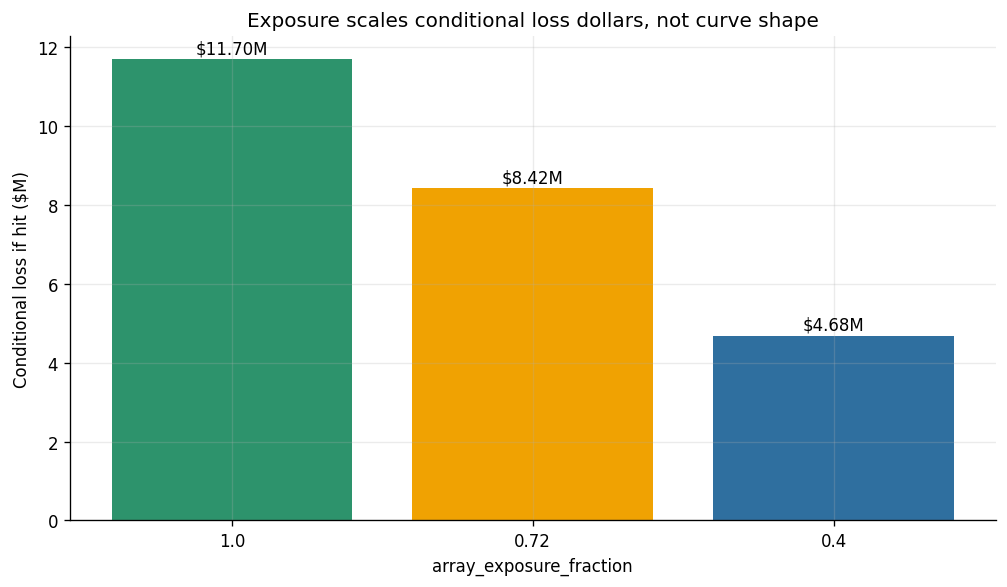

In [13]:
display(pd.DataFrame(artifact["exposure_logic"]))

example_D = 50.0
example_DR = float(logistic(example_D, p["D50_mm"], p["k_per_mm"]))
PV_ARRAY_value = 40_000_000
f_hail_material_share = 0.75
exposures = [1.0, 0.72, 0.40]
exposure_example = pd.DataFrame([
    {
        "mesh_mm": example_D,
        "failure_unit_DR_unstowed_default": example_DR,
        "PV_ARRAY_$M": PV_ARRAY_value / 1_000_000,
        "f_hail_material_share": f_hail_material_share,
        "array_exposure_fraction": e,
        "conditional_loss_$M": example_DR * PV_ARRAY_value * f_hail_material_share * e / 1_000_000,
    }
    for e in exposures
])
display(exposure_example.style.format({
    "failure_unit_DR_unstowed_default": "{:.3f}",
    "PV_ARRAY_$M": "${:.1f}",
    "conditional_loss_$M": "${:.2f}",
}))

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.bar([str(e) for e in exposures], exposure_example["conditional_loss_$M"], color=["#2d936c", "#f0a202", "#2f6f9f"])
ax.set_title("Exposure scales conditional loss dollars, not curve shape")
ax.set_xlabel("array_exposure_fraction")
ax.set_ylabel("Conditional loss if hit ($M)")
for i, val in enumerate(exposure_example["conditional_loss_$M"]):
    ax.text(i, val + 0.15, f"${val:.2f}M", ha="center")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "00_exposure_value_scaling.png", dpi=180, bbox_inches="tight")
plt.show()


## 13. What Ships In The Artifact

The curation process ships a machine-readable artifact, not just prose.

The key runtime fields are:

- `hazard_axis`
- `failure_units`
- `curve_records`
- `selector_logic`
- `conditioner_logic`
- `exposure_logic`
- `parameter_tier_table`
- `derivation_rationale`
- `emit_contract`
- `capability_declaration`

This is why the next notebook can consume the artifact directly.


In [14]:
artifact_summary = []
for key, value in artifact.items():
    if isinstance(value, list):
        summary = f"list[{len(value)}]"
    elif isinstance(value, dict):
        summary = f"dict keys: {', '.join(list(value.keys())[:6])}"
    else:
        summary = value
    artifact_summary.append({"artifact_key": key, "summary": summary})
display(pd.DataFrame(artifact_summary))

display(Markdown("**Derivation rationale**"))
display(pd.DataFrame([{"field": k, "value": v} for k, v in artifact["derivation_rationale"].items()]))


,artifact_key,summary
0,schema_version,damage_curve_record_bundle.v1
1,cell_id,hail_solar
2,damage_code_id,HAIL_SOLAR_PV_MODULE_V1
3,semantic_damage_model_version,model v1.0
4,documentation_revision,docs r5
5,package_release,library v2.5
6,canonical_runtime_artifact,True
7,source_dossier,01_cells/hail_solar/current/hail_solar_curve_derivation_dossier_v1_3.md
8,source_workbook,01_cells/hail_solar/current/damage_curve_records_v1_3_hail_solar_derivation_audit.xlsx
9,known_noncanonical_legacy_artifacts,list[1]


**Derivation rationale**

,field,value
0,source_spine,"Public PVEL/Kiwa hail stress sequence breakage anchors, with IEC baseline as near-zero certification anchor."
1,form_reasoning,Logistic form is a bounded monotone threshold-like model appropriate to sparse breakage probability anchors.
2,demoted_sources,Field performance and stow guidance inform mechanism/adjustment direction but do not supply universal numeric DR parameters.
3,tier_mix,Core unstowed archetype curves are mostly T2/T3; stow adjustment is T4 and must not support tail metrics.


## 14. Capability And Open Seams

The honest output today is scalar failure-unit DR and scenario loss when an explicit value/exposure basis exists.

The artifact does not carry a tail/spread distribution. So PML, VaR, and TVaR are withheld by the damage artifact. Annual risk metrics belong downstream after combining hazard frequency, hit sampling, value basis, and uncertainty treatment.


In [15]:
cap = artifact["capability_declaration"]
display(pd.DataFrame([
    {"metric": k, "status": v}
    for k, v in cap["metrics_supportable"].items()
]))

open_seams = pd.DataFrame([
    {"upgrade_area": "BOM-specific hail test reports", "what_it_replaces": "generic module archetype parameters"},
    {"upgrade_area": "Claims / replacement policy calibration", "what_it_replaces": "P_break ≈ replacement DR approximation"},
    {"upgrade_area": "Module BOM / cost allocation", "what_it_replaces": "generic f_hail_material_share/value-bucket assumptions"},
    {"upgrade_area": "Tracker/stow angle testing", "what_it_replaces": "+8mm D50 and 0.90 max_DR placeholder"},
    {"upgrade_area": "SCADA/event logs", "what_it_replaces": "assumed or scenario P(stowed)"},
    {"upgrade_area": "Site swath overlay", "what_it_replaces": "array_exposure_fraction = 1.0 default"},
])
display(open_seams)


,metric,status
0,failure_unit_scalar_dr,supported
1,scenario_loss_given_value_basis,supported_with_explicit_value_and_exposure_basis
2,scalar_eal,conditional_require_cap_binding_preflight
3,pml,withheld_no_tail_distribution
4,var,withheld_no_tail_distribution
5,tvar,withheld_no_tail_distribution


,upgrade_area,what_it_replaces
0,BOM-specific hail test reports,generic module archetype parameters
1,Claims / replacement policy calibration,P_break ≈ replacement DR approximation
2,Module BOM / cost allocation,generic f_hail_material_share/value-bucket assumptions
3,Tracker/stow angle testing,+8mm D50 and 0.90 max_DR placeholder
4,SCADA/event logs,assumed or scenario P(stowed)
5,Site swath overlay,array_exposure_fraction = 1.0 default


## 15. Reviewer Checklist

Use this before explaining or applying the curve:

- Is the x-axis MESH-equivalent diameter in mm?
- Is the curve applied to `PV_MODULE_GLASS_CELL`, not whole TIV?
- Is the selected `module_archetype` known, or did we default it?
- Are the base curve parameters evidence-backed and tiered?
- Is stow state known, scenario-based, or probabilistic?
- Is stow probability being confused with hail frequency? It should not be.
- Is `array_exposure_fraction` full-site default or geometry-derived?
- Is `f_hail_material_share` sourced or assumed?
- Are PML/VaR/TVaR withheld unless a downstream model supplies distribution/tail treatment?

The point of this framework is not to make every uncertainty disappear. It is to keep every uncertainty visible, named, and upgradeable.
